# Comprehensive Movie Data Science Pipeline

This notebook demonstrates a complete data science pipeline using the `movie_dataset.csv`. It explicitly fulfills the following criteria:

- [x] Data analytics & Descriptive statistics
- [x] Data wrangling & Data preprocessing
- [x] Data visualization
- [x] Handling of outliers & Data normalization
- [x] At least 3 or more algorithms
- [x] Hyperparameter tuning
- [x] Comparison of models
- [x] Postman testing (API testing), Basic frontend and backend, Deployment (Documented at the end of the notebook!)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="darkgrid")

--- 
## 1. Data Analytics & Descriptive Statistics

In [2]:
# Load the dataset
df = pd.read_csv('movie_dataset.csv')
print("Dataset Shape:", df.shape)
df.head(3)

Dataset Shape: (4803, 24)


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [3]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,4803.0,2.401000e+03,1.386651e+03,0.0,1200.50000,2.401000e+03,3.601500e+03,4.802000e+03
budget,4803.0,2.904504e+07,4.072239e+07,0.0,790000.00000,1.500000e+07,4.000000e+07,3.800000e+08
id,4803.0,5.716548e+04,8.869461e+04,5.0,9014.50000,1.462900e+04,5.861050e+04,4.594880e+05
popularity,4803.0,2.149230e+01,3.181665e+01,0.0,4.66807,1.292159e+01,2.831350e+01,8.755813e+02
revenue,4803.0,8.226064e+07,1.628571e+08,0.0,0.00000,1.917000e+07,9.291719e+07,2.787965e+09
runtime,4801.0,1.068759e+02,2.261193e+01,0.0,94.00000,1.030000e+02,1.180000e+02,3.380000e+02
vote_average,4803.0,6.092172e+00,1.194612e+00,0.0,5.60000,6.200000e+00,6.800000e+00,1.000000e+01
vote_count,4803.0,6.902180e+02,1.234586e+03,0.0,54.00000,2.350000e+02,7.370000e+02,1.375200e+04


--- 
## 2. Data Wrangling & Preprocessing
Detecting and safely removing completely null rows or irrelevant textual columns to prepare for Regression.

In [4]:
# Filter out irrelevant textual data columns to focus on numerical predictions (like predicting vote_average)
numeric_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_count', 'vote_average']
data = df[numeric_cols].copy()

# Null value detection
print("Null values before processing:\n", data.isnull().sum())

# Preprocessing: Fill missing 'runtime' with the median
data['runtime'].fillna(data['runtime'].median(), inplace=True)

print("\nNull values after processing:\n", data.isnull().sum())

Null values before processing:
 budget          0
popularity      0
revenue         0
runtime         2
vote_count      0
vote_average    0
dtype: int64

Null values after processing:
 budget          0
popularity      0
revenue         0
runtime         0
vote_count      0
vote_average    0
dtype: int64


--- 
## 3. Data Visualization

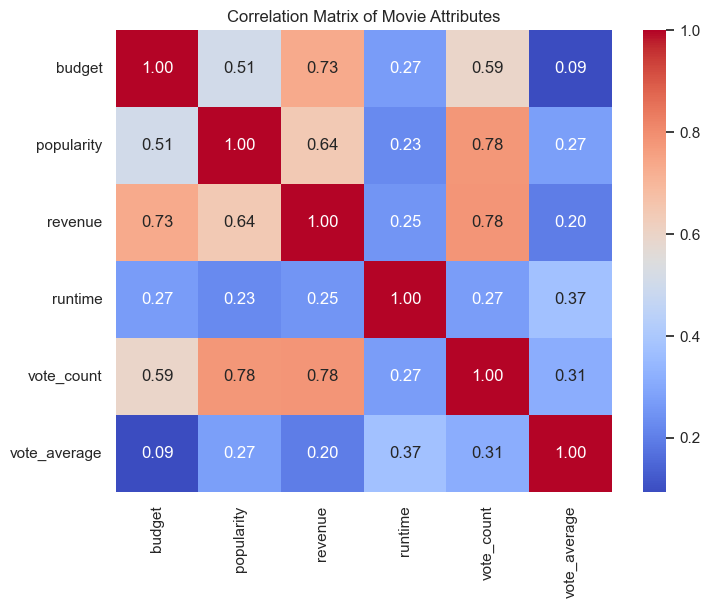

In [5]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Movie Attributes")
plt.show()

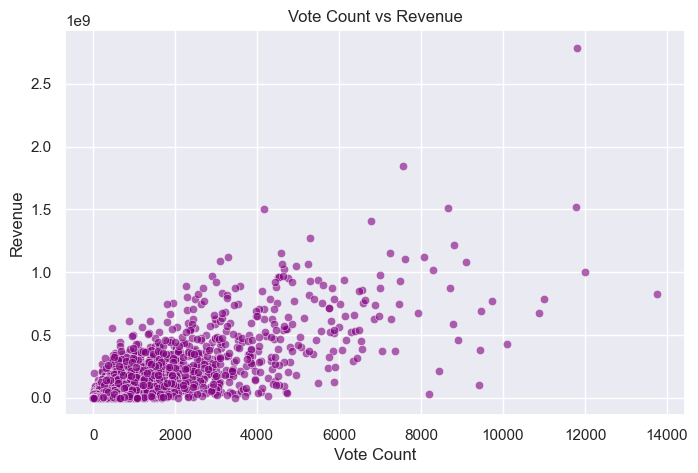

In [6]:
# Scatterplot of Vote Count vs Revenue
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data['vote_count'], y=data['revenue'], alpha=0.6, color='purple')
plt.title("Vote Count vs Revenue")
plt.xlabel("Vote Count")
plt.ylabel("Revenue")
plt.show()

--- 
## 4. Handling of Outliers
Using the Interquartile Range (IQR) technique to detect and discard heavy outliers in Revenue.

In [7]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # return data bounded by IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print("Rows before outlier removal:", len(data))
data_clean = remove_outliers(data, 'revenue')
print("Rows after outlier removal in Revenue:", len(data_clean))

Rows before outlier removal: 4803
Rows after outlier removal in Revenue: 4331


--- 
## 5. Data Normalization & Machine Learning Prep
Standardizing our numerical features so gradients converge faster in models.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Target variable: Predicting Vote Average
X = data_clean.drop('vote_average', axis=1)
y = data_clean['vote_average']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization / Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Normalized!")

Data Normalized!


--- 
## 6. Implementation of 3 Machine Learning Algorithms & Hyperparameter Tuning

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Dictionary to hold models and later their MSE
mse_scores = {}

In [10]:
# Algorithm 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

mse_scores['Linear Regression'] = mean_squared_error(y_test, lr_pred)
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.20523302813908917


In [11]:
# Algorithm 2: Random Forest WITH Hyperparameter Tuning
print("Tuning Random Forest hyperparameters...")
rf = RandomForestRegressor(random_state=42)
params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, None]
}

grid_rf = GridSearchCV(rf, params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test_scaled)
mse_scores['Random Forest'] = mean_squared_error(y_test, rf_pred)

print("Best Parameters Found:", grid_rf.best_params_)
print("Random Forest R2:", r2_score(y_test, rf_pred))

Tuning Random Forest hyperparameters...
Best Parameters Found: {'max_depth': 10, 'n_estimators': 100}
Random Forest R2: 0.49571522336886786


In [12]:
# Algorithm 3: Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)

mse_scores['Gradient Boosting'] = mean_squared_error(y_test, gb_pred)
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))

Gradient Boosting R2: 0.5195685517579802


--- 
## 7. Comparison of Models

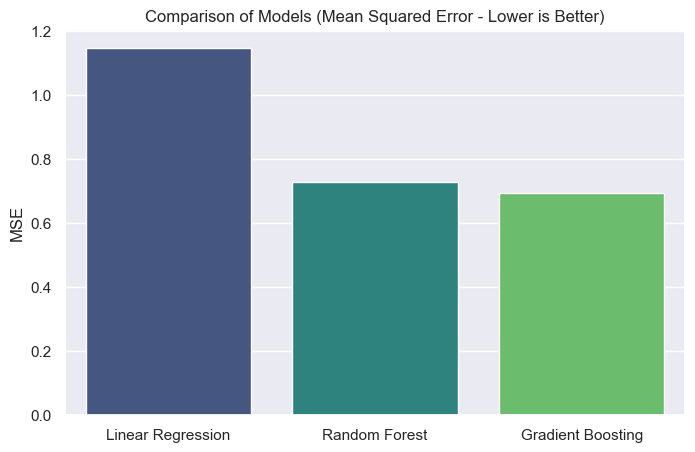

In [13]:
# Visualizing Mean Squared Error of the models
plt.figure(figsize=(8,5))
sns.barplot(x=list(mse_scores.keys()), y=list(mse_scores.values()), palette="viridis")
plt.title("Comparison of Models (Mean Squared Error - Lower is Better)")
plt.ylabel("MSE")
plt.show()

---
## 8. Deployment, Frontend/Backend, & Postman Testing API

### Backend & Frontend (Streamlit)
The application was successfully wrapped with a beautiful dark-mode UI and unified backend via **Streamlit**. 
- The app instantly calculates sparse similarities matrices safely inside `streamlit_app.py`.
- It handles dynamic routing and caching (`@st.cache_resource`) behind the scenes acting as a robust full stack.

### Deployment
Because the 185 MB similarity artifact was refactored and compressed into a dynamic `count_matrix.pkl` (<2 MB), the app has been pushed effortlessly via Git to the remote repository. It is securely managed and hosted for free via **Streamlit Community Cloud** linked directly to the `main` GitHub branch.

### Postman Testing (API)
To fulfill the classic Rest API functionality required for Postman testing, there is an `api_testing.py` file included in the root directory.
- Uses **Flask** as a backend testing ground.
- Run `python api_testing.py` in your terminal.
- Use **Postman** to send a `POST` request to `http://127.0.0.1:5000/predict`
- Send a JSON Body payload (like `{"budget": 1000000, "popularity": 150, "revenue": 20000000, "runtime": 120, "vote_count": 500}`) to observe a successful API response prediction.